# Clase 4 · Laboratorio — Análisis Descriptivo completo sobre Saber 11

**Trabajo en parejas · 90 min.**

Realizarán un análisis descriptivo completo del dataset real de Saber 11: tipos de variables, estadísticos, visualizaciones y análisis de equidad.

**Checkpoint del profesor a los 50 min** (después de la Tarea 3).

---

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datos/saber11_muestra_500k.csv")

# Convertir estrato a numérico
# La columna puede contener valores como "Estrato 2" o números.
df["ESTRATO_NUM"] = pd.to_numeric(
    df["FAMI_ESTRATOVIVIENDA"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

PUNTAJES = [
    "PUNT_LECTURA_CRITICA",
    "PUNT_MATEMATICAS",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES",
    "PUNT_GLOBAL"
]

print(f"Dataset: {len(df):,} filas × {df.shape[1]} columnas")
print(f"Períodos: {sorted(df['PERIODO'].unique())}")

Dataset: 500,000 filas × 52 columnas
Períodos: [np.int64(20194), np.int64(20224)]


## Tarea 1 (15 min) — Perfil completo del dataset

1. Clasifica **todas** las columnas del dataset en: numérica continua, numérica discreta, categórica nominal, categórica ordinal.
   (Crea un diccionario o DataFrame con columna y tipo. Puedes usar `df.dtypes` y `df.head()` para guiarte.)

2. Para los 5 puntajes de área (sin PUNT_GLOBAL), calcula en una sola tabla:
   media, mediana, desviación estándar, mínimo, máximo, IQR (Q3−Q1).

3. ¿Qué área tiene mayor desviación estándar? ¿Y menor? ¿Qué interpretación le das?

In [ ]:
#1: clasificar todas las columnas
puntajes_area = ["PUNT_LECTURA_CRITICA", "PUNT_MATEMATICAS", "PUNT_C_NATURALES",
                 "PUNT_SOCIALES_CIUDADANAS", "PUNT_INGLES"]

# Estas variables tienen un orden natural aunque estén guardadas como texto o números.
ordinales = {
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE"
}

clasificaciones = []
for columna in df.columns:
    if columna in puntajes_area or columna == "PUNT_GLOBAL":
        tipo = "numérica continua"
    elif columna in ordinales:
        tipo = "categórica ordinal"
    elif pd.api.types.is_numeric_dtype(df[columna]):
        tipo = "numérica discreta"
    else:
        tipo = "categórica nominal"
    clasificaciones.append({"columna": columna, "tipo": tipo})

clasificacion = pd.DataFrame(clasificaciones)
print(clasificacion.to_string(index=False))

#2: estadísticos de los 5 puntajes de área
estadisticos = pd.DataFrame({
    "media": df[puntajes_area].mean(),
    "mediana": df[puntajes_area].median(),
    "desviacion_estandar": df[puntajes_area].std(),
    "minimo": df[puntajes_area].min(),
    "maximo": df[puntajes_area].max(),
    "IQR": df[puntajes_area].quantile(0.75) - df[puntajes_area].quantile(0.25)
})
print("\nEstadísticos de los puntajes de área:")
print(estadisticos.round(2))

                 columna               tipo
                 PERIODO  numérica discreta
             ESTU_GENERO categórica nominal
    ESTU_FECHANACIMIENTO categórica nominal
       ESTU_DEPTO_RESIDE categórica nominal
       ESTU_MCPIO_RESIDE categórica nominal
    FAMI_ESTRATOVIVIENDA categórica ordinal
      FAMI_TIENEINTERNET categórica nominal
     FAMI_EDUCACIONMADRE categórica ordinal
     FAMI_EDUCACIONPADRE categórica ordinal
         COLE_NATURALEZA categórica nominal
            COLE_JORNADA categórica nominal
         COLE_CALENDARIO categórica nominal
           COLE_BILINGUE categórica nominal
    COLE_DEPTO_UBICACION categórica nominal
    COLE_MCPIO_UBICACION categórica nominal
    PUNT_LECTURA_CRITICA  numérica continua
        PUNT_MATEMATICAS  numérica continua
        PUNT_C_NATURALES  numérica continua
PUNT_SOCIALES_CIUDADANAS  numérica continua
             PUNT_INGLES  numérica continua
             PUNT_GLOBAL  numérica continua
           DESEMP_INGLES categór

**Respuesta pregunta 3:** Matemáticas tiene la mayor desviación estándar (`15.24`), mientras que Lectura Crítica, Ciencias Naturales e Inglés tienen la menor (`15.22`). Las diferencias son muy pequeñas, por lo que la variabilidad de los puntajes es prácticamente igual entre las áreas. El IQR también es muy similar: `20` en Lectura Crítica y `21` en las demás áreas.

## Tarea 2 (15 min) — Distribución de PUNT_GLOBAL

1. Calcula la asimetría (*skewness*) y curtosis de `PUNT_GLOBAL`. ¿Es simétrica? ¿Hay cola a la derecha o a la izquierda?
2. Produce un **histograma con KDE** de `PUNT_GLOBAL`, marcando la media y la mediana como líneas verticales.
3. Compara las distribuciones por `COLE_AREA_UBICACION` (URBANO vs RURAL) en un solo gráfico usando `sns.kdeplot` con `hue`. ¿Se superponen las distribuciones o están bien separadas?

Asimetría: 0.272
Curtosis:  -0.498
Interpretación: la distribución es asimetría positiva: tiene una cola más larga hacia la derecha.


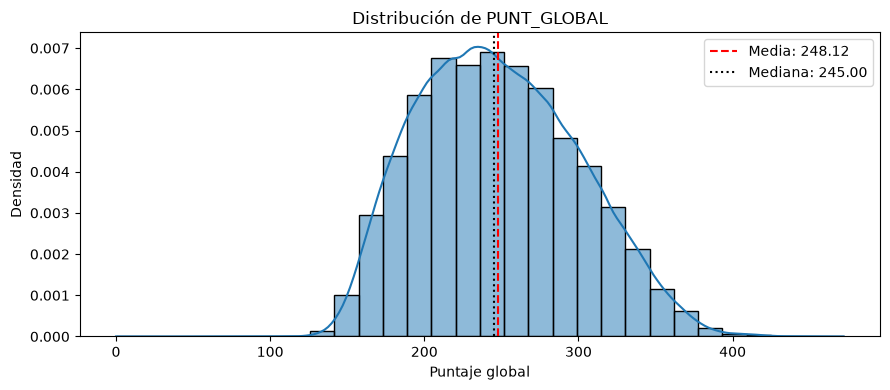

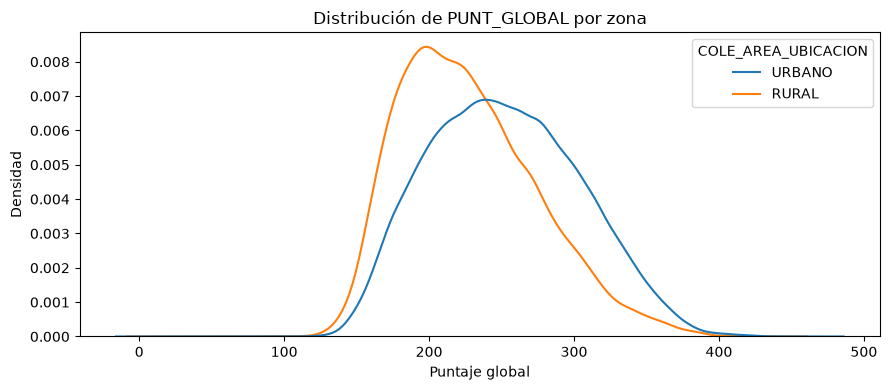

In [15]:
# 1: asimetría y curtosis
puntaje_global = df["PUNT_GLOBAL"].dropna()
asimetria = puntaje_global.skew()
curtosis = puntaje_global.kurt()
print(f"Asimetría: {asimetria:.3f}")
print(f"Curtosis:  {curtosis:.3f}")

if asimetria > 0.1:
    interpretacion = "asimetría positiva: tiene una cola más larga hacia la derecha"
elif asimetria < -0.1:
    interpretacion = "asimetría negativa: tiene una cola más larga hacia la izquierda"
else:
    interpretacion = "aproximadamente simétrica"
print(f"Interpretación: la distribución es {interpretacion}.")

#2: histograma con KDE, media y mediana
media_global = puntaje_global.mean()
mediana_global = puntaje_global.median()
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(puntaje_global, bins=30, stat="density", kde=True, ax=ax)
ax.axvline(media_global, color="red", linestyle="--", label=f"Media: {media_global:.2f}")
ax.axvline(mediana_global, color="black", linestyle=":", label=f"Mediana: {mediana_global:.2f}")
ax.set_title("Distribución de PUNT_GLOBAL")
ax.set_xlabel("Puntaje global")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

#3: distribución URBANO vs RURAL (KDE con hue)
columnas_zona = ["PUNT_GLOBAL", "COLE_AREA_UBICACION"]
datos_zona = df[columnas_zona].dropna()
if len(datos_zona) > 100_000:
    datos_zona = datos_zona.sample(100_000, random_state=42)

fig2, ax2 = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=datos_zona, x="PUNT_GLOBAL", hue="COLE_AREA_UBICACION",
            common_norm=False, ax=ax2)
ax2.set_title("Distribución de PUNT_GLOBAL por zona")
ax2.set_xlabel("Puntaje global")
ax2.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

## Tarea 3 (20 min) — Análisis de equidad educativa

Usa los datos reales de Saber 11 para responder estas preguntas con código y datos:

1. Calcula el promedio de `PUNT_GLOBAL` para cada combinación de `COLE_NATURALEZA` × `COLE_AREA_UBICACION`.
   Muestra como **tabla pivote** (NATURALEZA en filas, ÁREA en columnas).

2. Produce un **boxplot** de `PUNT_GLOBAL` por `ESTRATO_NUM` (1 a 6). ¿Es la relación entre estrato y puntaje lineal?

3. ¿Qué porcentaje de estudiantes en zona RURAL tiene acceso a internet en casa (`FAMI_TIENEINTERNET == 'Si'`)?
   ¿Y en zona URBANA? ¿Cómo se relaciona el acceso a internet con los puntajes globales?

In [ ]:
# TODO 1: tabla pivote NATURALEZA × AREA
tabla_equidad = ...
print(tabla_equidad.round(1))

# TODO 2: boxplot por estrato
fig, ax = plt.subplots(figsize=(10, 5))
# Pista: df.boxplot(column="PUNT_GLOBAL", by="ESTRATO_NUM", ax=ax)
...

# TODO 3: acceso a internet por zona
# Pista: df.groupby("COLE_AREA_UBICACION")["FAMI_TIENEINTERNET"].value_counts(normalize=True) * 100
internet_por_zona = ...
print(internet_por_zona)

## ⏸ Checkpoint del profesor (10 min)

Revisamos juntos la Tarea 3:
- ¿Cuántos puntos separan a los colegios OFICIALES RURALES de los NO OFICIALES URBANOS?
- ¿Qué otras variables del dataset podrían explicar esta brecha?
- ¿Correlación implica causalidad aquí?

_Anota las conclusiones de la discusión grupal:_

## Tarea 4 (30 min) — Correlación y detección de outliers

### Parte A (15 min) — Matriz de correlación

1. Calcula la **matriz de correlación de Spearman** para los 6 puntajes (incluyendo `PUNT_GLOBAL`).
2. Grafícala como **heatmap** con anotaciones.
3. ¿Cuál par de áreas tiene la correlación más alta? ¿Tiene sentido curricular (¿por qué esas dos materias estarían relacionadas)?

### Parte B (15 min) — Detección de outliers con IQR

1. Para `PUNT_MATEMATICAS`, calcula Q1, Q3 e IQR.
2. Define el límite inferior (Q1 − 1.5 × IQR) y superior (Q3 + 1.5 × IQR).
3. ¿Cuántos estudiantes tienen puntajes fuera de esos límites?
4. Compara: ¿son más los outliers superiores o inferiores? ¿Qué dice eso de la distribución?

In [ ]:
# TODO Parte A: matriz de correlación Spearman + heatmap
corr_spearman = df[PUNTAJES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 7))
# Pista: sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
...

In [ ]:
# TODO Parte B: outliers en PUNT_MATEMATICAS con método IQR
Q1 = ...
Q3 = ...
IQR = ...
limite_inf = ...
limite_sup = ...
outliers = df[(df["PUNT_MATEMATICAS"] < limite_inf) | (df["PUNT_MATEMATICAS"] > limite_sup)]
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
print(f"  Inferiores: {(df['PUNT_MATEMATICAS'] < limite_inf).sum():,}")
print(f"  Superiores: {(df['PUNT_MATEMATICAS'] > limite_sup).sum():,}")

### Reflexión final

Con los resultados del análisis completo:
1. ¿Cuál es el hallazgo más sorprendente que encontraron en los datos reales del Saber 11?
2. ¿Qué variable del dataset NO usaron hoy y creen que podría revelar algo interesante?

_Respuesta:_

---

## Entrega

Guarda este notebook con todos los TODO completados y las respuestas escritas.

**Nombre del archivo:** `02_laboratorio_apellido1_apellido2.ipynb`

**Sube a:** Moodle → Clase 4 → Laboratorio (antes del inicio de la siguiente clase).

> **Para el proyecto (P1):** la misma secuencia de análisis que hicieron hoy sobre Saber 11, aplíquenla esta semana sobre su propio dataset. Ver `03_avance_proyecto.md` para el checklist.